## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful")

Setup successful


In [3]:
charts_path = "../data/raw/spotify_charts.csv"
churn_path = "../data/raw/spotify_user_churn.csv"

charts_df = pd.read_csv(charts_path)
churn_df = pd.read_csv(churn_path)

print("Charts dataset shape:", charts_df.shape)
print("Churn dataset shape:", churn_df.shape)

Charts dataset shape: (26173514, 9)
Churn dataset shape: (1000, 10)


In [4]:
print("Charts columns:")
print(charts_df.columns)

print("\nChurn columns:")
print(churn_df.columns)

Charts columns:
Index(['title', 'rank', 'date', 'artist', 'url', 'region', 'chart', 'trend',
       'streams'],
      dtype='object')

Churn columns:
Index(['user_id', 'subscription_type', 'country', 'avg_daily_minutes',
       'number_of_playlists', 'top_genre', 'skips_per_day', 'support_tickets',
       'days_since_last_login', 'churned'],
      dtype='object')


## Data Cleaning & Processing

In [6]:
charts_df.info()
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26173514 entries, 0 to 26173513
Data columns (total 9 columns):
 #   Column   Dtype  
---  ------   -----  
 0   title    object 
 1   rank     int64  
 2   date     object 
 3   artist   object 
 4   url      object 
 5   region   object 
 6   chart    object 
 7   trend    object 
 8   streams  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 1.8+ GB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                1000 non-null   object 
 1   subscription_type      1000 non-null   object 
 2   country                1000 non-null   object 
 3   avg_daily_minutes      1000 non-null   float64
 4   number_of_playlists    1000 non-null   int64  
 5   top_genre              1000 non-null   object 
 6   skips_per_day          1000 non-null   int64  
 7   sup

In [9]:
charts_df.isnull().sum()

title           11
rank             0
date             0
artist          18
url              0
region           0
chart            0
trend            0
streams    5851610
dtype: int64

In [10]:
churn_df.isnull().sum()

user_id                  0
subscription_type        0
country                  0
avg_daily_minutes        0
number_of_playlists      0
top_genre                0
skips_per_day            0
support_tickets          0
days_since_last_login    0
churned                  0
dtype: int64

In [11]:
charts_df.groupby("chart")["streams"].apply(lambda x: x.isnull().mean())

chart
top200     0.0
viral50    1.0
Name: streams, dtype: float64

In [12]:
charts_df["date"] = pd.to_datetime(charts_df["date"], errors="coerce")

print("Minimum date:", charts_df["date"].min())
print("Maximum date:", charts_df["date"].max())
print("Failed date conversions:", charts_df["date"].isnull().sum())

Minimum date: 2017-01-01 00:00:00
Maximum date: 2021-12-31 00:00:00
Failed date conversions: 0


In [13]:
print(charts_df["chart"].value_counts())

chart
top200     20321904
viral50     5851610
Name: count, dtype: int64


In [14]:
print(charts_df["trend"].value_counts())

trend
MOVE_DOWN        11220434
MOVE_UP           9801048
SAME_POSITION     3298392
NEW_ENTRY         1853640
Name: count, dtype: int64


In [15]:
print("Number of regions:", charts_df["region"].nunique())

Number of regions: 70


In [16]:
print(churn_df["churned"].value_counts())
print("Churn rate:", churn_df["churned"].mean())

churned
0    814
1    186
Name: count, dtype: int64
Churn rate: 0.186


In [17]:
print("Negative avg daily minutes:", (churn_df["avg_daily_minutes"] < 0).sum())
print("Negative playlists:", (churn_df["number_of_playlists"] < 0).sum())
print("Negative skips:", (churn_df["skips_per_day"] < 0).sum())
print("Negative support tickets:", (churn_df["support_tickets"] < 0).sum())
print("Negative days since login:", (churn_df["days_since_last_login"] < 0).sum())

Negative avg daily minutes: 7
Negative playlists: 0
Negative skips: 0
Negative support tickets: 0
Negative days since login: 0


In [18]:
churn_summary = churn_df.groupby("churned").agg({
    "avg_daily_minutes": "mean",
    "number_of_playlists": "mean",
    "skips_per_day": "mean",
    "support_tickets": "mean",
    "days_since_last_login": "mean"
})

churn_summary

,avg_daily_minutes,number_of_playlists,skips_per_day,support_tickets,days_since_last_login
churned,,,,,
0,103.272359,3.632678,4.692875,0.183047,8.841523
1,71.926882,2.564516,4.360215,0.446237,12.360215


viral50 has no stream values, top200 has stream values. Need to be treated differently.

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

charts_path = RAW_DIR / "spotify_charts.csv"
churn_path = RAW_DIR / "spotify_user_churn.csv"


In [21]:
# Count invalid values before cleaning
negative_minutes_count = (churn_df["avg_daily_minutes"] < 0).sum()
print("Negative avg_daily_minutes before cleaning:", negative_minutes_count)

# Replace negative minutes with NaN
churn_df.loc[churn_df["avg_daily_minutes"] < 0, "avg_daily_minutes"] = np.nan

# Fill missing avg_daily_minutes with the median of valid values
median_minutes = churn_df["avg_daily_minutes"].median()
churn_df["avg_daily_minutes"] = churn_df["avg_daily_minutes"].fillna(median_minutes)

# Confirm cleaning worked
print("Negative avg_daily_minutes after cleaning:", (churn_df["avg_daily_minutes"] < 0).sum())
print("Missing avg_daily_minutes after cleaning:", churn_df["avg_daily_minutes"].isnull().sum())
print("Median used:", median_minutes)

Negative avg_daily_minutes before cleaning: 0
Negative avg_daily_minutes after cleaning: 0
Missing avg_daily_minutes after cleaning: 0
Median used: 98.2


In [22]:
duplicate_users = churn_df["user_id"].duplicated().sum()
print("Duplicate user IDs:", duplicate_users)

Duplicate user IDs: 0


In [23]:
clean_churn_path = PROCESSED_DIR / "spotify_user_churn_clean.csv"

churn_df.to_csv(clean_churn_path, index=False)

print("Saved clean churn dataset to:", clean_churn_path)
print(churn_df.shape)

Saved clean churn dataset to: ../data/processed/spotify_user_churn_clean.csv
(1000, 10)


In [24]:
charts_df = pd.read_csv(
    charts_path,
    dtype={
        "title": "string",
        "rank": "int16",
        "artist": "string",
        "url": "string",
        "region": "category",
        "chart": "category",
        "trend": "category",
        "streams": "float32"
    },
    parse_dates=["date"]
)

print(charts_df.shape)
charts_df.info(memory_usage="deep")

(26173514, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26173514 entries, 0 to 26173513
Data columns (total 9 columns):
 #   Column   Dtype         
---  ------   -----         
 0   title    string        
 1   rank     int16         
 2   date     datetime64[ns]
 3   artist   string        
 4   url      string        
 5   region   category      
 6   chart    category      
 7   trend    category      
 8   streams  float32       
dtypes: category(3), datetime64[ns](1), float32(1), int16(1), string(3)
memory usage: 6.8 GB


In [25]:
charts_df = charts_df.dropna(subset=["title", "artist"]).copy()

In [26]:
top200_df = charts_df[charts_df["chart"] == "top200"].copy()
viral50_df = charts_df[charts_df["chart"] == "viral50"].copy()

print("Top 200 shape:", top200_df.shape)
print("Viral 50 shape:", viral50_df.shape)

Top 200 shape: (20321897, 9)
Viral 50 shape: (5851588, 9)


In [31]:
viral50_df = viral50_df.drop(columns=["streams"])

KeyError: "['streams'] not found in axis"

In [32]:
top200_path = PROCESSED_DIR / "charts_top200_clean.parquet"
viral50_path = PROCESSED_DIR / "charts_viral50_clean.parquet"

top200_df.to_parquet(top200_path, index=False)
viral50_df.to_parquet(viral50_path, index=False)

print("Saved Top 200 file to:", top200_path)
print("Saved Viral 50 file to:", viral50_path)

Saved Top 200 file to: ../data/processed/charts_top200_clean.parquet
Saved Viral 50 file to: ../data/processed/charts_viral50_clean.parquet


In [33]:
top200_test = pd.read_parquet(top200_path)
viral50_test = pd.read_parquet(viral50_path)
churn_test = pd.read_csv(clean_churn_path)

print("Top 200 test shape:", top200_test.shape)
print("Viral 50 test shape:", viral50_test.shape)
print("Churn test shape:", churn_test.shape)

Top 200 test shape: (20321897, 9)
Viral 50 test shape: (5851588, 8)
Churn test shape: (1000, 10)


## Churn Dataset EDA

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

churn_path = PROCESSED_DIR / "spotify_user_churn_clean.csv"

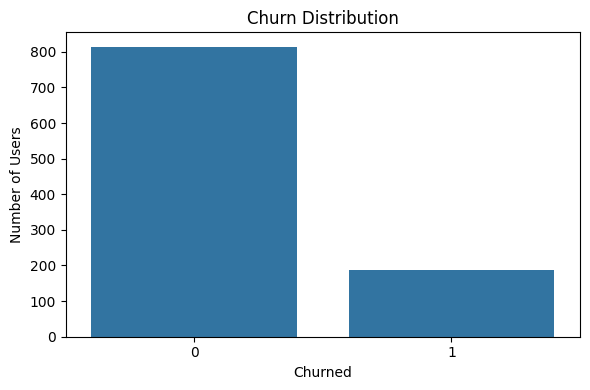

In [35]:
plt.figure(figsize=(6, 4))
sns.countplot(data=churn_df, x="churned")
plt.title("Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "churn_distribution.png", dpi=300)
plt.show()

In [36]:
numeric_features = [
    "avg_daily_minutes",
    "number_of_playlists",
    "skips_per_day",
    "support_tickets",
    "days_since_last_login"
]

churn_numeric_summary = churn_df.groupby("churned")[numeric_features].mean().T
churn_numeric_summary["difference"] = churn_numeric_summary[1] - churn_numeric_summary[0]
churn_numeric_summary

churned,0,1,difference
avg_daily_minutes,103.855405,73.760753,-30.094653
number_of_playlists,3.632678,2.564516,-1.068162
skips_per_day,4.692875,4.360215,-0.332660
support_tickets,0.183047,0.446237,0.263190
days_since_last_login,8.841523,12.360215,3.518692


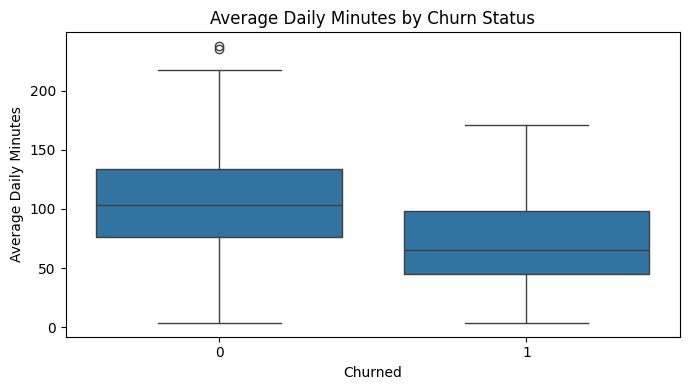

In [37]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=churn_df, x="churned", y="avg_daily_minutes")
plt.title("Average Daily Minutes by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Average Daily Minutes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "avg_daily_minutes_by_churn.png", dpi=300)
plt.show()

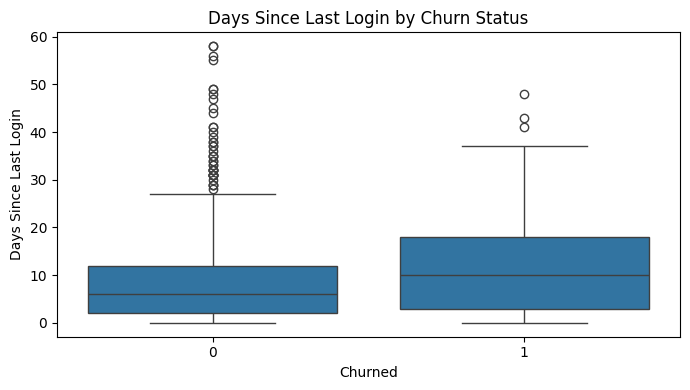

In [38]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=churn_df, x="churned", y="days_since_last_login")
plt.title("Days Since Last Login by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Days Since Last Login")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "days_since_last_login_by_churn.png", dpi=300)
plt.show()

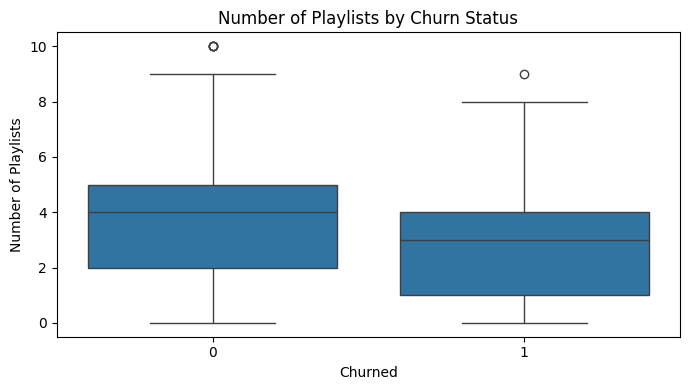

In [39]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=churn_df, x="churned", y="number_of_playlists")
plt.title("Number of Playlists by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Number of Playlists")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "number_of_playlists_by_churn.png", dpi=300)
plt.show()

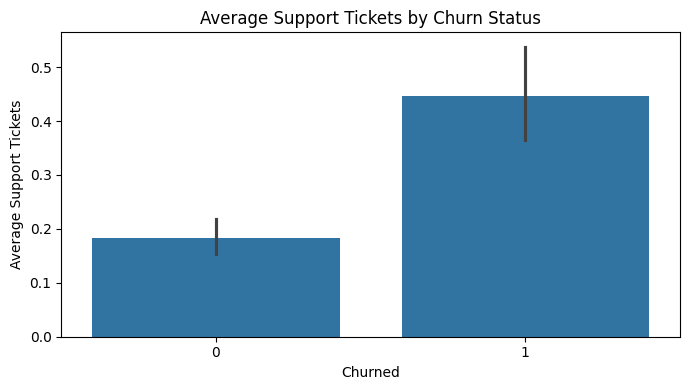

In [40]:
plt.figure(figsize=(7, 4))
sns.barplot(data=churn_df, x="churned", y="support_tickets")
plt.title("Average Support Tickets by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Average Support Tickets")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "support_tickets_by_churn.png", dpi=300)
plt.show()

In [42]:
subscription_churn = churn_df.groupby("subscription_type")["churned"].mean().sort_values(ascending=False)
subscription_churn

subscription_type
Free       0.352480
Premium    0.082658
Name: churned, dtype: float64

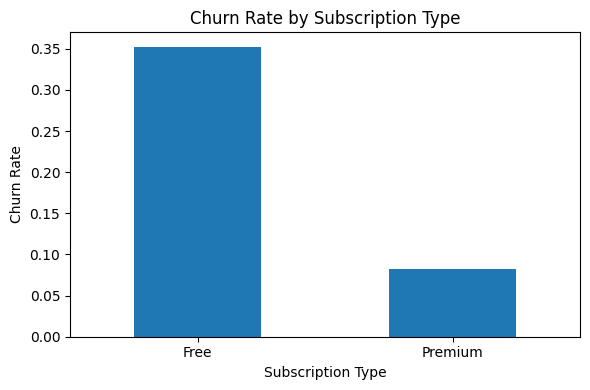

In [44]:
plt.figure(figsize=(6, 4))
subscription_churn.plot(kind="bar")
plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "churn_by_subscription_type.png", dpi=300)
plt.show()

In [46]:
genre_churn = churn_df.groupby("top_genre")["churned"].agg(["mean", "count"]).sort_values("mean", ascending=False)

genre_churn

,mean,count
top_genre,,
Jazz,0.215385,130
Hip-Hop,0.209150,153
Electronic,0.204225,142
Country,0.202454,163
Classical,0.186207,145
Rock,0.170068,147
Pop,0.100000,120


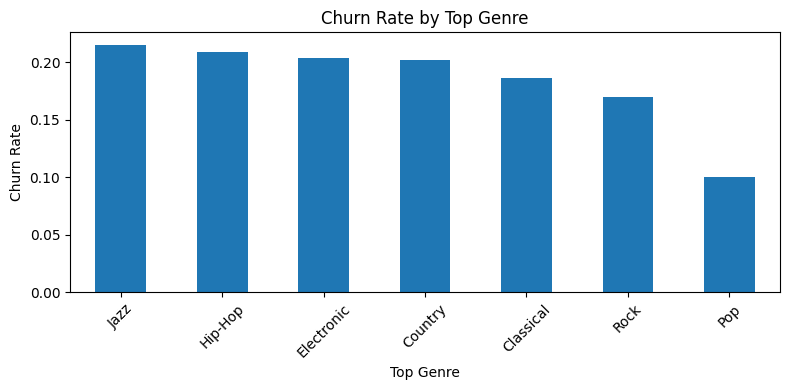

In [47]:
plt.figure(figsize=(8, 4))
genre_churn["mean"].sort_values(ascending=False).plot(kind="bar")
plt.title("Churn Rate by Top Genre")
plt.xlabel("Top Genre")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "churn_by_top_genre.png", dpi=300)
plt.show()

In [48]:
country_churn = churn_df.groupby("country")["churned"].agg(["mean", "count"]).sort_values("mean", ascending=False)

country_churn.head(15)

,mean,count
country,,
AU,0.267327,101
DE,0.230000,100
US,0.223404,94
CA,0.217822,101
IN,0.204082,98
FR,0.160000,100
BR,0.156250,96
RU,0.153846,104
PK,0.152381,105


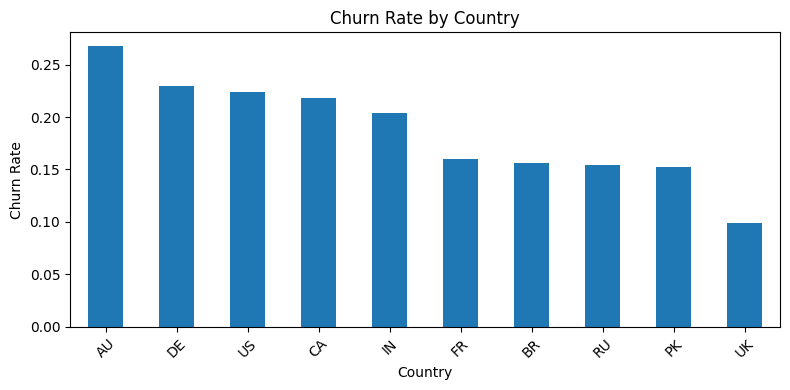

In [49]:
plt.figure(figsize=(8, 4))
country_churn["mean"].sort_values(ascending=False).plot(kind="bar")
plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "churn_by_country.png", dpi=300)
plt.show()

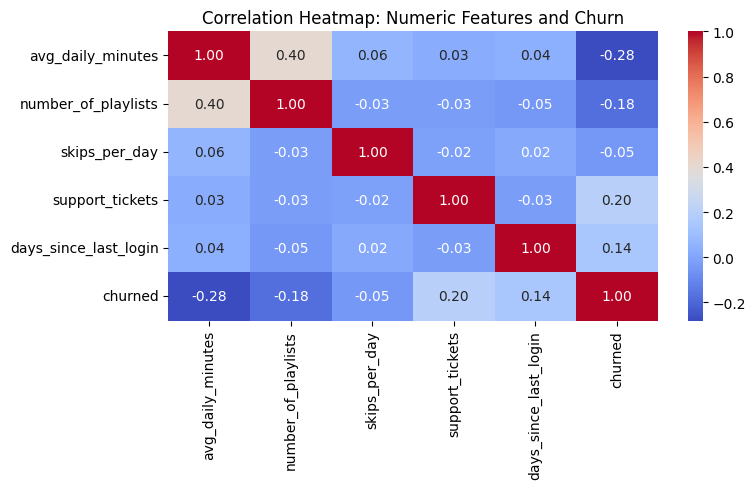

In [50]:
corr = churn_df[numeric_features + ["churned"]].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Numeric Features and Churn")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "churn_correlation_heatmap.png", dpi=300)
plt.show()

## Churn EDA Interpretation

The churn dataset contains 1,000 users, with churn represented as 1 and non-churn represented as 0. The initial analysis shows clear behavioral differences between churned and non-churned users.

## Numeric Feature Differences

Churned users show lower platform engagement compared with non-churned users. Non-churned users listen for an average of 103.86 minutes per day, while churned users listen for only 73.76 minutes per day. This is a difference of around 30 fewer minutes per day, suggesting that lower daily listening activity is strongly associated with churn.

Churned users also have fewer playlists. Non-churned users have an average of 3.63 playlists, while churned users have an average of 2.56 playlists. This suggests that users who create or maintain more playlists may be more invested in the platform and therefore less likely to leave.

Interestingly, churned users have slightly fewer skips per day than non-churned users. Non-churned users average 4.69 skips per day, while churned users average 4.36 skips per day. This suggests that skips may not be a strong churn signal in this dataset. A higher skip count could simply mean that active users listen more and therefore skip more songs overall.

Support tickets appear to be more clearly related to churn. Churned users submit an average of 0.45 support tickets, compared with 0.18 for non-churned users. This suggests that user friction, complaints, or unresolved issues may increase the likelihood of churn.

Overall, the most important early churn signals appear to be:

- lower average daily listening time
- fewer playlists
- more support tickets

## Subscription Type and Churn

Churn also differs strongly by subscription type. Free users have a churn rate of 35.25%, while Premium users have a churn rate of only 8.27%.

This suggests that Premium users are much more likely to stay on the platform. This may be because Premium users have already made a financial commitment to Spotify, experience fewer limitations, and may receive more value from the service. Free users, on the other hand, may be more casual and less attached to the platform.